In [1]:
import pandas as pd

df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
df.shape

(200, 5)

In [3]:
df.columns

Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='str')

In [4]:
df = df.drop("Unnamed: 0", axis=1)

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
df.dtypes

TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

In [6]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [7]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

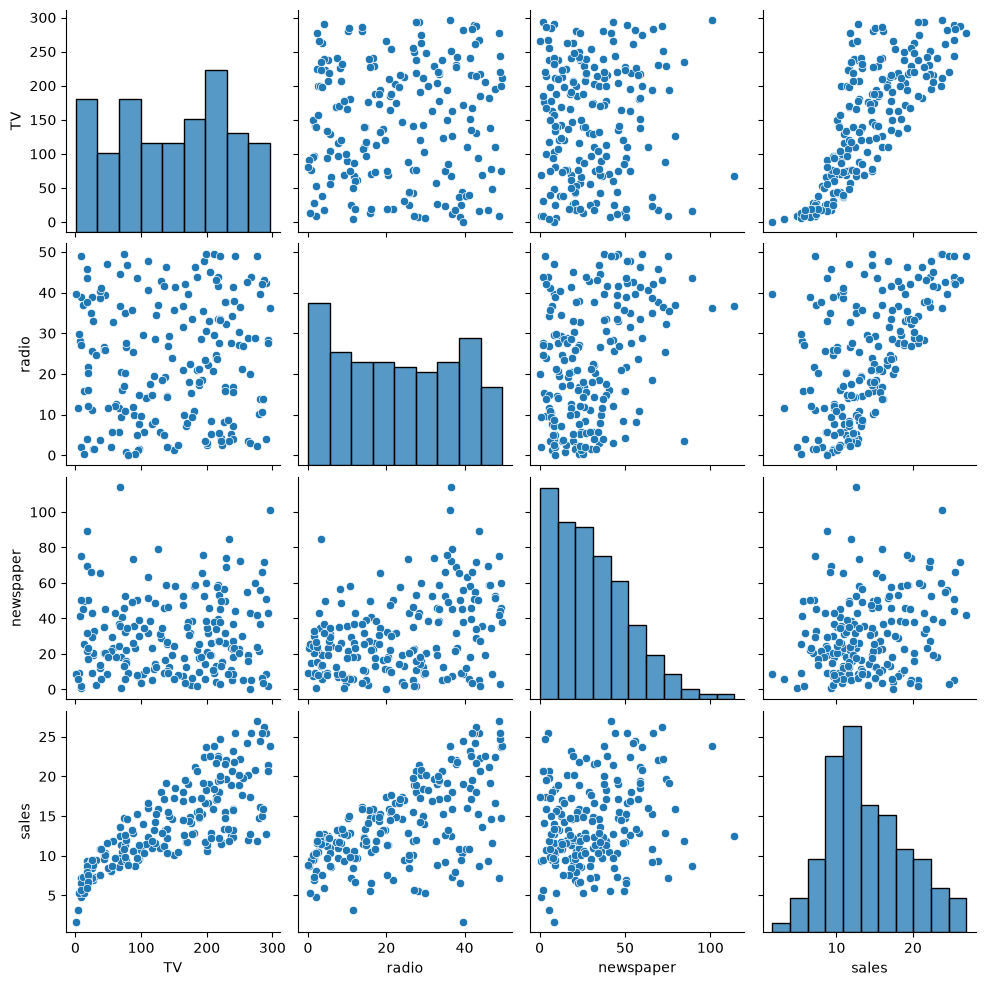

In [9]:
sns.pairplot(df)
plt.show()

### Observation

The pairplot shows the relationships between advertising expenditure and sales. Sales generally increase as TV and radio advertising expenditure increase, suggesting positive relationships with sales. The relationship between newspaper advertising and sales appears comparatively weaker.

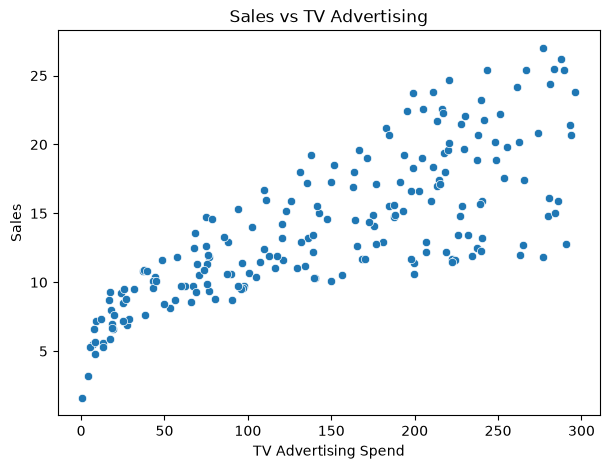

In [10]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="TV", y="sales")
plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()

### Observation

The scatter plot shows a clear positive relationship between TV advertising expenditure and sales. In general, higher TV advertising spending is associated with higher sales, although the points do not fall exactly on a single line.

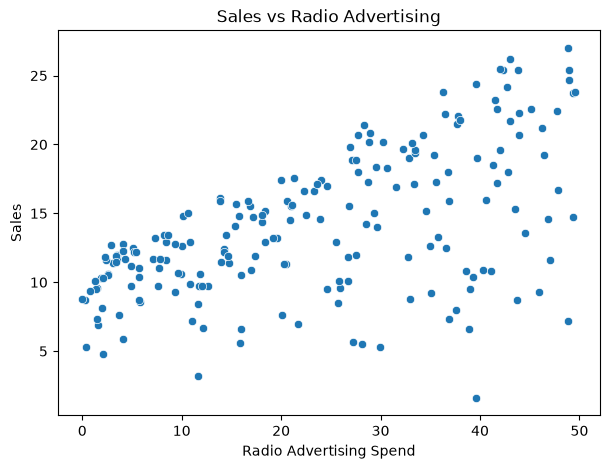

In [11]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="radio", y="sales")
plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.show()

### Observation

The scatter plot shows a positive relationship between radio advertising expenditure and sales. As radio advertising spending increases, sales generally tend to increase, although the relationship has some variation across the observations.

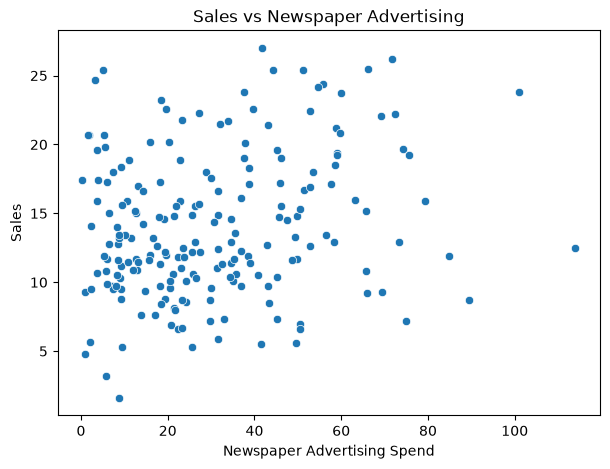

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="newspaper", y="sales")
plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.show()

### Observation

The scatter plot shows a weaker relationship between newspaper advertising expenditure and sales compared with TV and radio advertising. The points are more widely scattered, suggesting that newspaper advertising has a relatively smaller contribution to predicting sales in this dataset.

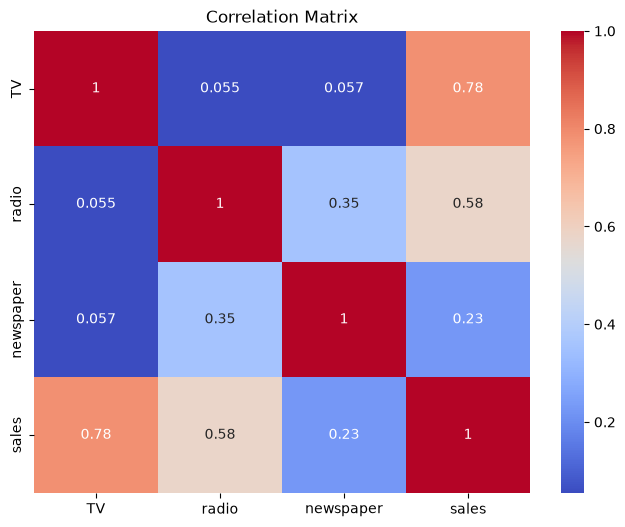

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### Observation

The correlation heatmap/matrix shows that sales have a strong positive correlation with TV advertising and a positive correlation with radio advertising. Newspaper advertising has a comparatively weaker correlation with sales. This supports the patterns observed in the scatter plots and suggests that TV and radio are more useful predictors of sales in this dataset.

In [14]:
from sklearn.model_selection import train_test_split

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [15]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

# Random Forest metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

print("\nRandom Forest Regression")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Linear Regression
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912

Random Forest Regression
MAE : 0.6203249999999988
RMSE: 0.7687170968568338
R²  : 0.9812782416450916


### Model Evaluation Observation

The Random Forest Regression model performed better than the Linear Regression model on the test data. Random Forest achieved a lower MAE of approximately **0.6203** and a lower RMSE of approximately **0.7687**, compared with 1.4608 and 1.7816 for Linear Regression. It also achieved a higher R² score of approximately **0.9813**, compared with **0.8994** for Linear Regression.

Therefore, Random Forest Regression was selected as the best-performing model for this dataset based on these evaluation metrics.

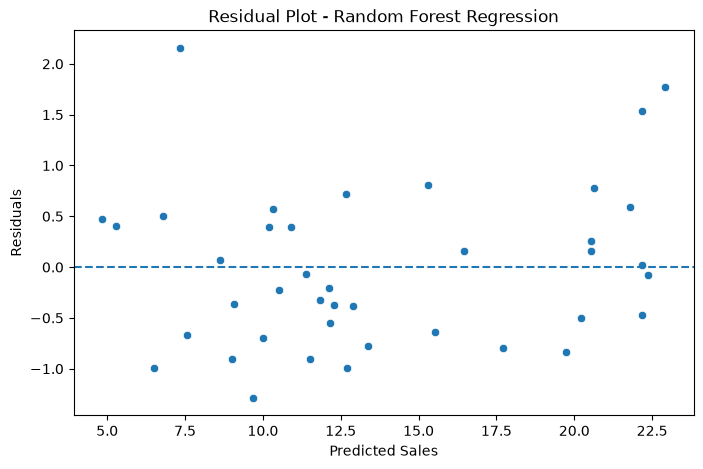

In [18]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_rf, y=residuals)

plt.axhline(y=0, linestyle="--")
plt.title("Residual Plot - Random Forest Regression")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

### Residual Plot Observation

The residual plot shows how the prediction errors are distributed around the zero line. The residuals are generally scattered around zero without a strong systematic pattern, suggesting that the Random Forest model provides a good fit to the test data.

TV           0.624810
radio        0.362214
newspaper    0.012976
dtype: float64


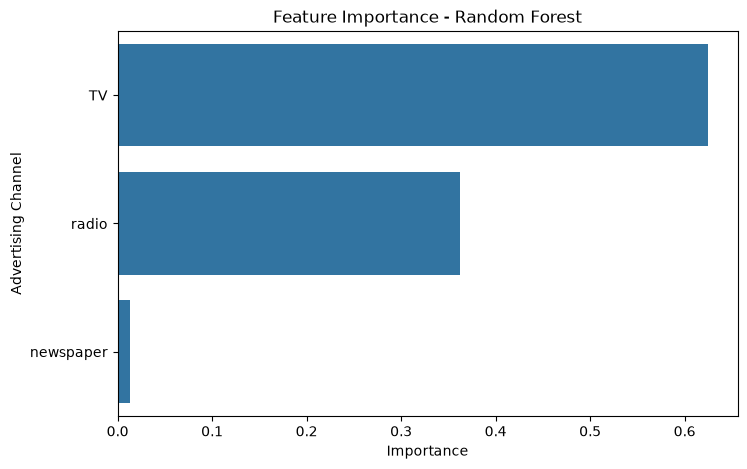

In [19]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")
plt.show()

### Feature Importance Interpretation

The feature importance analysis from the Random Forest Regression model shows that **TV advertising has the highest importance (0.6248)** in predicting sales. Radio advertising is the second most important feature with an importance of **0.3622**. Newspaper advertising has a much lower importance of **0.0130**.

This indicates that TV advertising contributes the most to the model's predictions of sales, while newspaper advertising contributes very little compared with TV and radio.

These feature importance values describe the model's predictive importance and should not be interpreted as proof of direct causation.

## Conclusion

This project analyzed the relationship between advertising expenditure and product sales using exploratory data analysis and machine learning.

The dataset was cleaned by removing the unnecessary index column and checking for missing values and data types. Exploratory visualizations, including pairplots, scatter plots, and a correlation heatmap, were used to understand relationships between advertising channels and sales.

Two regression models were trained: Linear Regression and Random Forest Regression. The Random Forest model performed better on the test data, achieving an R² score of approximately **0.9813**, compared with **0.8994** for Linear Regression. It also achieved lower MAE and RMSE values.

Feature importance analysis showed that **TV advertising was the most important feature**, followed by Radio, while Newspaper had relatively low importance.

Overall, the analysis demonstrates how machine learning can be used to predict sales from advertising expenditure and identify which advertising channels are most useful for the model's predictions.